In [1]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# Data folders for all available laser intensities.
# The 1.7 PW/cm^2 dataset is stored deeper in the original ECBB_model archive.
data_folders = {
    1.0: Path("ECBB_model/1.0PW_cm^2"),
    1.3: Path("ECBB_model/1.3PW_cm^2"),
    1.6: Path("ECBB_model/1.6PW_cm^2"),
    1.7: Path("ECBB_model/data/data_Neon/ECBB_model/1.7PW_cm^2"),
}

event_files = {
    "all": "momenta_all_events.txt",
    "direct": "momenta_direct_events.txt",
    "delayed": "momenta_delayed_events.txt",
}

files = {
    (intensity, event_class): folder / filename
    for intensity, folder in data_folders.items()
    for event_class, filename in event_files.items()
}

pd.DataFrame(
    [
        {
            "intensity_PW_cm2": intensity,
            "event_class": event_class,
            "path": str(path),
            "exists": path.exists(),
        }
        for (intensity, event_class), path in files.items()
    ]
)


,intensity_PW_cm2,event_class,path,exists
0,1.0,all,ECBB_model\1.0PW_cm^2\momenta_all_events.txt,True
1,1.0,direct,ECBB_model\1.0PW_cm^2\momenta_direct_events.txt,True
2,1.0,delayed,ECBB_model\1.0PW_cm^2\momenta_delayed_events.txt,True
3,1.3,all,ECBB_model\1.3PW_cm^2\momenta_all_events.txt,True
4,1.3,direct,ECBB_model\1.3PW_cm^2\momenta_direct_events.txt,True
5,1.3,delayed,ECBB_model\1.3PW_cm^2\momenta_delayed_events.txt,True
6,1.6,all,ECBB_model\1.6PW_cm^2\momenta_all_events.txt,True
7,1.6,direct,ECBB_model\1.6PW_cm^2\momenta_direct_events.txt,True
8,1.6,delayed,ECBB_model\1.6PW_cm^2\momenta_delayed_events.txt,True
9,1.7,all,ECBB_model\data\data_Neon\ECBB_model\1.7PW_cm^...,True


In [3]:
# Column order in every momentum file.
all_columns = [
    "p1x", "p1y", "p1z",
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z",
]

# Particle 1 is the ion/core and is not included in the PCA input.
electron_columns = [
    "p2x", "p2y", "p2z",
    "p3x", "p3y", "p3z",
    "p4x", "p4y", "p4z",
]

longitudinal_components = ["p2z", "p3z", "p4z"]
selected_pcs = ["PC1", "PC8", "PC9"]


In [4]:
# Read one dataset and return only the nine electron momentum components.
def read_electron_data(file_path):
    df = pd.read_csv(
        file_path,
        sep=",",
        header=None,
        names=all_columns,
        skipinitialspace=True,
    )

    df_e = (
        df[electron_columns]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .reset_index(drop=True)
    )

    return df_e


In [5]:
# PCA procedure used identically for every intensity and event class.
def run_pca(file_path):
    df_e = read_electron_data(file_path)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_e)

    model = PCA()
    scores = model.fit_transform(X_scaled)

    pc_names = [f"PC{i + 1}" for i in range(len(electron_columns))]

    loadings = pd.DataFrame(
        model.components_.T,
        index=electron_columns,
        columns=pc_names,
    )

    explained_variance = pd.DataFrame({
        "PC": pc_names,
        "explained_variance_ratio": model.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(model.explained_variance_ratio_),
    })

    return {
        "data": df_e,
        "scaler": scaler,
        "model": model,
        "scores": scores,
        "loadings": loadings,
        "explained_variance": explained_variance,
    }


In [6]:
# Run PCA for all 12 datasets:
# 4 laser intensities x {all, direct, delayed}.
results = {}

for (intensity, event_class), file_path in files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing dataset: {file_path}")

    results[(intensity, event_class)] = run_pca(file_path)

print(f"PCA completed for {len(results)} datasets.")


PCA completed for 12 datasets.


In [7]:
# Number of events in every analysed dataset.
event_counts = pd.DataFrame(
    [
        {
            "intensity_PW_cm2": intensity,
            "event_class": event_class,
            "n_events": len(result["data"]),
        }
        for (intensity, event_class), result in results.items()
    ]
).sort_values(["intensity_PW_cm2", "event_class"]).reset_index(drop=True)

display(event_counts)


,intensity_PW_cm2,event_class,n_events
0,1.0,all,4872
1,1.0,delayed,2097
2,1.0,direct,2042
3,1.3,all,13769
4,1.3,delayed,5837
5,1.3,direct,6198
6,1.6,all,18578
7,1.6,delayed,7560
8,1.6,direct,8799
9,1.7,all,3873


In [8]:
# Explained variance of every principal component for every dataset.
variance_rows = []

for (intensity, event_class), result in results.items():
    table = result["explained_variance"]

    for _, row in table.iterrows():
        variance_rows.append({
            "intensity_PW_cm2": intensity,
            "event_class": event_class,
            "PC": row["PC"],
            "explained_variance_ratio": row["explained_variance_ratio"],
            "cumulative_explained_variance": row["cumulative_explained_variance"],
        })

variance_summary = (
    pd.DataFrame(variance_rows)
    .sort_values(["intensity_PW_cm2", "event_class", "PC"])
    .reset_index(drop=True)
)

display(variance_summary)


,intensity_PW_cm2,event_class,PC,explained_variance_ratio,cumulative_explained_variance
0,1.0,all,PC1,0.239257,0.239257
1,1.0,all,PC2,0.124728,0.363984
2,1.0,all,PC3,0.120408,0.484392
3,1.0,all,PC4,0.116410,0.600802
4,1.0,all,PC5,0.111203,0.712005
...,...,...,...,...,...
103,1.7,direct,PC5,0.113155,0.775462
104,1.7,direct,PC6,0.097264,0.872726
105,1.7,direct,PC7,0.089999,0.962725
106,1.7,direct,PC8,0.022677,0.985403


In [9]:
# Variance carried by the three PCA directions used in the longitudinal interpretation.
selected_variance = (
    variance_summary[variance_summary["PC"].isin(selected_pcs)]
    .copy()
    .sort_values(["intensity_PW_cm2", "event_class", "PC"])
    .reset_index(drop=True)
)

display(selected_variance)


,intensity_PW_cm2,event_class,PC,explained_variance_ratio,cumulative_explained_variance
0,1.0,all,PC1,0.239257,0.239257
1,1.0,all,PC8,0.048743,0.954570
2,1.0,all,PC9,0.045430,1.000000
3,1.0,delayed,PC1,0.192083,0.192083
4,1.0,delayed,PC8,0.081144,0.940900
5,1.0,delayed,PC9,0.059100,1.000000
6,1.0,direct,PC1,0.300261,0.300261
7,1.0,direct,PC8,0.019030,0.985384
8,1.0,direct,PC9,0.014616,1.000000
9,1.3,all,PC1,0.247302,0.247302


In [10]:
# Longitudinal loadings of PC1, PC8 and PC9 for all intensities and event classes.
loading_rows = []

for (intensity, event_class), result in results.items():
    loadings = result["loadings"]

    for pc in selected_pcs:
        p2z, p3z, p4z = loadings.loc[longitudinal_components, pc].to_numpy()

        loading_rows.append({
            "intensity_PW_cm2": intensity,
            "event_class": event_class,
            "PC": pc,
            "p2z": p2z,
            "p3z": p3z,
            "p4z": p4z,
            "z_norm": np.sqrt(p2z**2 + p3z**2 + p4z**2),
            "sum_z_loadings": p2z + p3z + p4z,
        })

longitudinal_loadings = (
    pd.DataFrame(loading_rows)
    .sort_values(["intensity_PW_cm2", "event_class", "PC"])
    .reset_index(drop=True)
)

display(longitudinal_loadings)


,intensity_PW_cm2,event_class,PC,p2z,p3z,p4z,z_norm,sum_z_loadings
0,1.0,all,PC1,0.579538,0.571808,0.577622,0.998236,1.728968
1,1.0,all,PC8,-0.339156,0.816006,-0.466553,0.999282,0.010297
2,1.0,all,PC9,0.739205,-0.075301,-0.666307,0.998027,-0.002403
3,1.0,delayed,PC1,0.562671,0.535205,0.619327,0.993282,1.717203
4,1.0,delayed,PC8,-0.610381,0.764349,-0.105328,0.983813,0.048639
5,1.0,delayed,PC9,-0.531574,-0.330050,0.766879,0.989751,-0.094745
6,1.0,direct,PC1,0.579672,0.577214,0.571931,0.998149,1.728818
7,1.0,direct,PC8,-0.282930,-0.516517,0.807745,0.999645,0.008297
8,1.0,direct,PC9,0.763142,-0.631352,-0.136295,0.999784,-0.004506
9,1.3,all,PC1,0.573951,0.576263,0.581523,0.999834,1.731736


In [11]:
# Comparison with the fixed collective/relative directions used later in the thesis.
e0 = np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)
e1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
e2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)

alignment_rows = []

for _, row in longitudinal_loadings.iterrows():
    z_vector = row[["p2z", "p3z", "p4z"]].to_numpy(dtype=float)
    z_norm = np.linalg.norm(z_vector)

    if z_norm == 0:
        z_unit = np.full(3, np.nan)
    else:
        z_unit = z_vector / z_norm

    alignment_rows.append({
        "intensity_PW_cm2": row["intensity_PW_cm2"],
        "event_class": row["event_class"],
        "PC": row["PC"],
        "z_fraction_of_loading_norm": z_norm**2,
        "abs_dot_e0_collective": abs(np.dot(z_unit, e0)),
        "abs_dot_e1_p2_minus_p3": abs(np.dot(z_unit, e1)),
        "abs_dot_e2_pair23_vs_p4": abs(np.dot(z_unit, e2)),
    })

direction_alignment = (
    pd.DataFrame(alignment_rows)
    .sort_values(["intensity_PW_cm2", "event_class", "PC"])
    .reset_index(drop=True)
)

display(direction_alignment)


,intensity_PW_cm2,event_class,PC,z_fraction_of_loading_norm,abs_dot_e0_collective,abs_dot_e1_p2_minus_p3,abs_dot_e2_pair23_vs_p4
0,1.0,all,PC1,0.996475,0.999984,0.005476,0.001594
1,1.0,all,PC8,0.998564,0.005949,0.817410,0.576026
2,1.0,all,PC9,0.996059,0.001390,0.577081,0.816686
3,1.0,delayed,PC1,0.986609,0.998133,0.019553,0.057861
4,1.0,delayed,PC8,0.967888,0.028544,0.988075,0.151306
5,1.0,delayed,PC9,0.979606,0.055268,0.143975,0.988037
6,1.0,direct,PC1,0.996301,0.999984,0.001741,0.005327
7,1.0,direct,PC8,0.999291,0.004792,0.165229,0.986244
8,1.0,direct,PC9,0.999568,0.002602,0.986270,0.165123
9,1.3,all,PC1,0.999667,0.999985,0.001635,0.005240


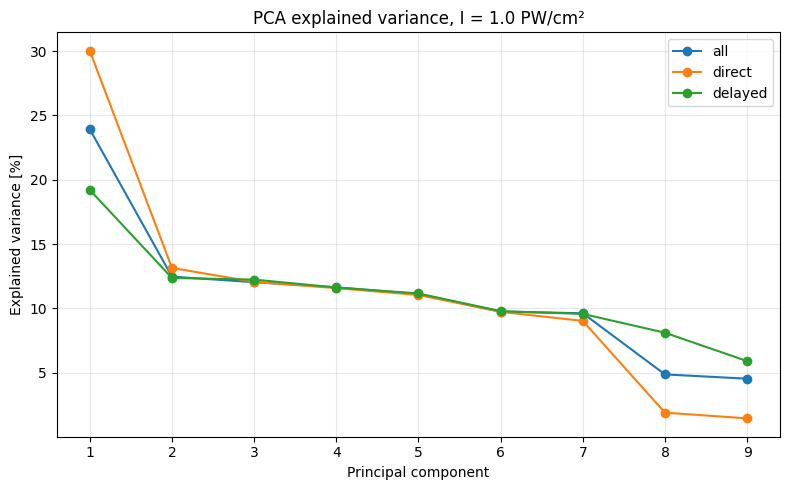

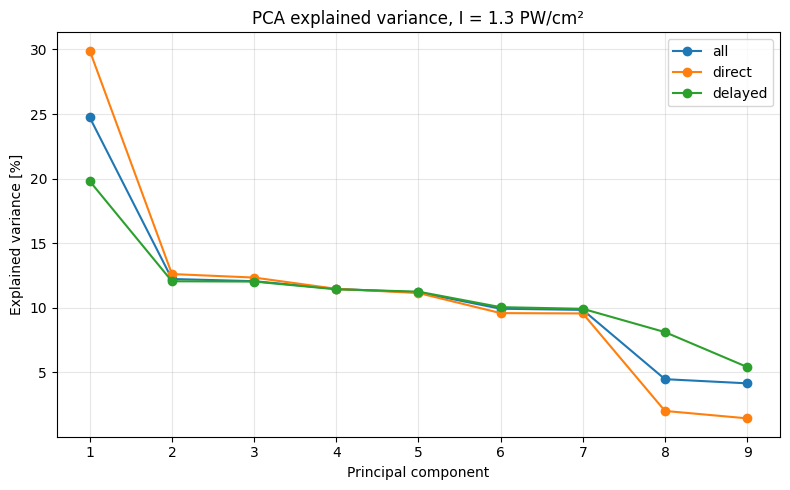

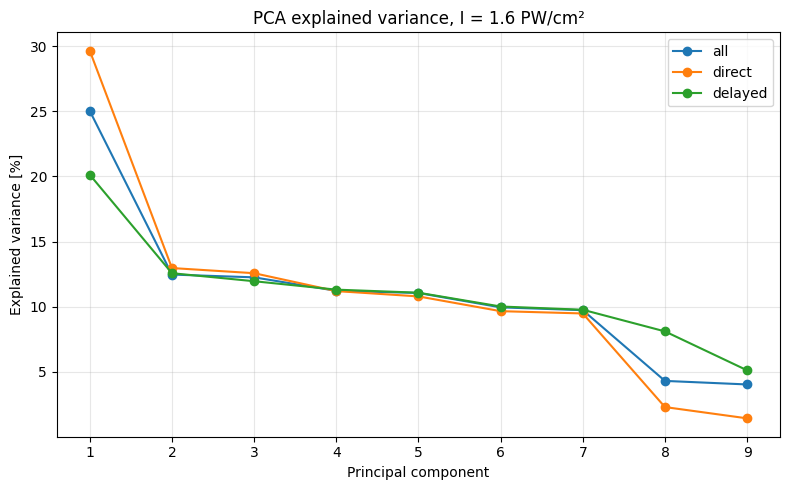

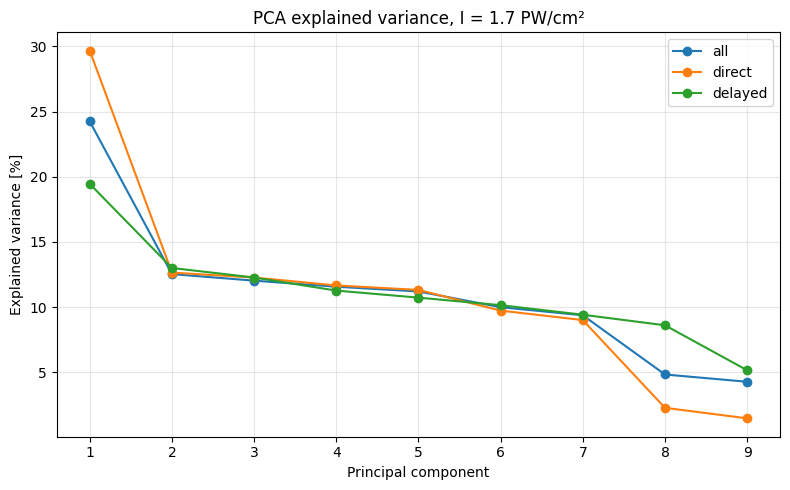

In [12]:
# Scree plots for each intensity.
# Each plot compares all events, direct events and delayed events.
for intensity in sorted(data_folders):
    plt.figure(figsize=(8, 5))

    for event_class in event_files:
        table = results[(intensity, event_class)]["explained_variance"]
        x = np.arange(1, len(table) + 1)
        y = 100 * table["explained_variance_ratio"].to_numpy()

        plt.plot(x, y, marker="o", label=event_class)

    plt.xlabel("Principal component [—]")
    plt.ylabel("Explained variance [%]")
    plt.title(f"PCA explained variance, I = {intensity:.1f} PW/cm²")
    plt.xticks(range(1, 10))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


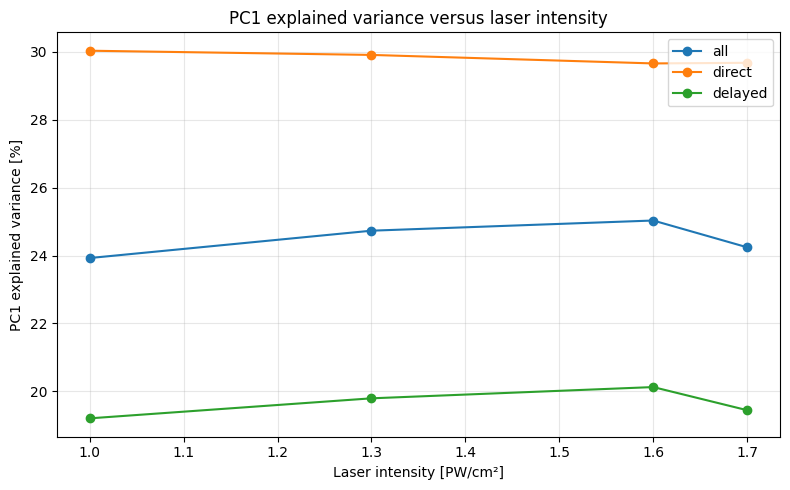

In [13]:
# Dependence of PC1 explained variance on laser intensity.
pc1_by_intensity = variance_summary[variance_summary["PC"] == "PC1"].copy()

plt.figure(figsize=(8, 5))

for event_class in event_files:
    subset = pc1_by_intensity[pc1_by_intensity["event_class"] == event_class]
    plt.plot(
        subset["intensity_PW_cm2"],
        100 * subset["explained_variance_ratio"],
        marker="o",
        label=event_class,
    )

plt.xlabel("Laser intensity [PW/cm²]")
plt.ylabel("PC1 explained variance [%]")
plt.title("PC1 explained variance versus laser intensity")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# Compact table for the thesis discussion:
# PC1, PC8 and PC9 longitudinal coefficients for direct and delayed events.
direct_delayed_loadings = longitudinal_loadings[
    longitudinal_loadings["event_class"].isin(["direct", "delayed"])
].copy()

display(
    direct_delayed_loadings[
        ["intensity_PW_cm2", "event_class", "PC", "p2z", "p3z", "p4z", "z_norm"]
    ]
)


,intensity_PW_cm2,event_class,PC,p2z,p3z,p4z,z_norm
3,1.0,delayed,PC1,0.562671,0.535205,0.619327,0.993282
4,1.0,delayed,PC8,-0.610381,0.764349,-0.105328,0.983813
5,1.0,delayed,PC9,-0.531574,-0.330050,0.766879,0.989751
6,1.0,direct,PC1,0.579672,0.577214,0.571931,0.998149
7,1.0,direct,PC8,-0.282930,-0.516517,0.807745,0.999645
8,1.0,direct,PC9,0.763142,-0.631352,-0.136295,0.999784
12,1.3,delayed,PC1,0.541619,0.555920,0.628831,0.998913
13,1.3,delayed,PC8,0.731189,-0.668827,-0.036802,0.991626
14,1.3,delayed,PC9,-0.405394,-0.483117,0.775536,0.999602
15,1.3,direct,PC1,0.579744,0.580675,0.571307,0.999839


In [15]:
# Save numerical summaries so that the results can be reused directly in the thesis.
output_dir = Path("PCA_results")
output_dir.mkdir(exist_ok=True)

event_counts.to_csv(output_dir / "event_counts.csv", index=False)
variance_summary.to_csv(output_dir / "explained_variance.csv", index=False)
selected_variance.to_csv(output_dir / "selected_pc_variance.csv", index=False)
longitudinal_loadings.to_csv(output_dir / "longitudinal_loadings.csv", index=False)
direction_alignment.to_csv(output_dir / "direction_alignment.csv", index=False)

print(f"Saved PCA summary tables to: {output_dir.resolve()}")


Saved PCA summary tables to: C:\Users\koran\Documents\UJ\Semestr 4\praktyka\praca-licencjacka\praca-licencjacka\PCA_results
